# Module 3 — DFT Calculations for Solids: Aluminum (a simple metal)

Build up a full periodic-solid DFT workflow: a single SCF run, Ecut / k-point convergence with a Brillouin-zone picture, an equation of state and bulk modulus, and finally a band structure with orbital-projected density of states.


**Learning objectives**
- Distinguish primitive cell, conventional cell, and supercell for a metal
- Run a periodic SCF calculation with a sensible first-guess Ecut/k-mesh
- Converge total energy with respect to plane-wave cutoff and k-point mesh
- Visualize the Brillouin zone and its high-symmetry points
- Fit an equation of state to get the equilibrium lattice constant and bulk modulus
- Compute and interpret a band structure and projected density of states


## Setup: installing Quantum ESPRESSO

First, we install Quantum ESPRESSO (QE) using **Ubuntu's own `apt` package repository**

In [ ]:
!apt-get update -qq
!apt-get install -qq -y quantum-espresso
!pip install -q ase==3.23.0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package quantum-espresso.
Preparing to unpack .../quantum-espresso_6.7-2build1_amd64.deb ...
Unpacking quantum-espresso (6.7-2build1) ...
Selecting previously unselected package quantum-espresso-data.
Preparing to unpack .../quantum-espresso-data_6.7-2build1_all.deb ...
Unpacking quantum-espresso-data (6.7-2build1) ...
Setting up quantum-espresso-data (6.7-2build1) ...
Setting up libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Setting up quantum-espresso (6.7-2build1) ...
Processing triggers for libc-bin (2.35-0ubunt

In [ ]:
# Quick sanity check before going any further: confirm pw.x (a system
# binary from apt) and ase (a Python package from pip) are both reachable.
!which pw.x
!which projwfc.x
import ase
print('ase', ase.__version__, '->', ase.__file__)


/usr/bin/pw.x
/usr/bin/projwfc.x
ase 3.23.0 -> /usr/local/lib/python3.12/dist-packages/ase/__init__.py


In [ ]:
from ase.calculators.espresso import EspressoProfile

# Same as previous notebook
profile = EspressoProfile(command='pw.x', pseudo_dir='pseudo')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.visualize.plot import plot_atoms
from ase.calculators.espresso import Espresso
from ase.eos import EquationOfState

plt.rcParams['figure.dpi'] = 110


### Getting pseudopotentials (GBRV library)

Quantum ESPRESSO needs a pseudopotential file (`.UPF`) for every element in the calculation. We use the **GBRV library** (Garrity, Bennett, Rabe & Vanderbilt, *Comput. Mater. Sci.* 81, 446 (2014)) — a comprehensive, well-tested ultrasoft pseudopotential. We download the whole library once, keep only the files we need, and rename them from GBRV's own naming convention (e.g. `o_pbe_v1.2.uspp.F.UPF`) to the simple `O.UPF` that ASE/QE expect.

In [ ]:
# Download and unpack the GBRV pseudopotential library, then rename each
# file from GBRV's convention (e.g. 'o_pbe_v1.2.uspp.F.UPF') to the plain
# 'O.UPF' that ASE/QE expect. NOTE: keep this wget on a single line --
# splitting a quoted URL across a '!'-prefixed line with a trailing
# backslash does NOT reliably concatenate in Colab and silently breaks
# into two separate (broken) URLs.
!mkdir -p pseudo
!wget -q -O gbrv.tar.gz https://www.physics.rutgers.edu/gbrv/all_pbe_UPF_v1.5.tar.gz
!tar -xzf gbrv.tar.gz -C pseudo

import glob, os, shutil

for f in glob.glob('pseudo/*_*.UPF'):
    new_name = os.path.basename(f).split('_')[0].capitalize() + '.UPF'
    shutil.move(f, os.path.join('pseudo', new_name))

# We only actually need a few elements here: Al
print(sorted(glob.glob('pseudo/*.UPF'))[:10], '...')


['pseudo/Ag.UPF', 'pseudo/Al.UPF', 'pseudo/As.UPF', 'pseudo/Au.UPF', 'pseudo/B.UPF', 'pseudo/Ba.UPF', 'pseudo/Be.UPF', 'pseudo/Bi.UPF', 'pseudo/Br.UPF', 'pseudo/C.UPF'] ...


In [ ]:
def pseudo_filename(symbol):
    return f'{symbol}.UPF'

def recommended_cutoffs(symbol):
    """GBRV is designed around one uniform cutoff rather than per-element
    values: ~40 Ry for ecutwfc, and since these are ultrasoft
    pseudopotentials, ecutrho should be 8-12x that (we use 8x)."""
    return 40, 320


In [ ]:
pseudopotentials = {'Al': pseudo_filename('Al')}
rec_ecutwfc, rec_ecutrho = recommended_cutoffs('Al')
print(f'GBRV recommends ecutwfc={rec_ecutwfc} Ry, ecutrho={rec_ecutrho} Ry as a starting point -- we will still verify this ourselves below.')


GBRV recommends ecutwfc=40 Ry, ecutrho=320 Ry as a starting point -- we will still verify this ourselves below.


## Part 0 — Primitive cell, conventional cell, supercell (quick recap)

Same pattern as Module 1, now specifically for Al (FCC).

Primitive cell:    1 atom(s)
Conventional cell: 4 atom(s)
2x2x2 supercell:   8 atom(s)


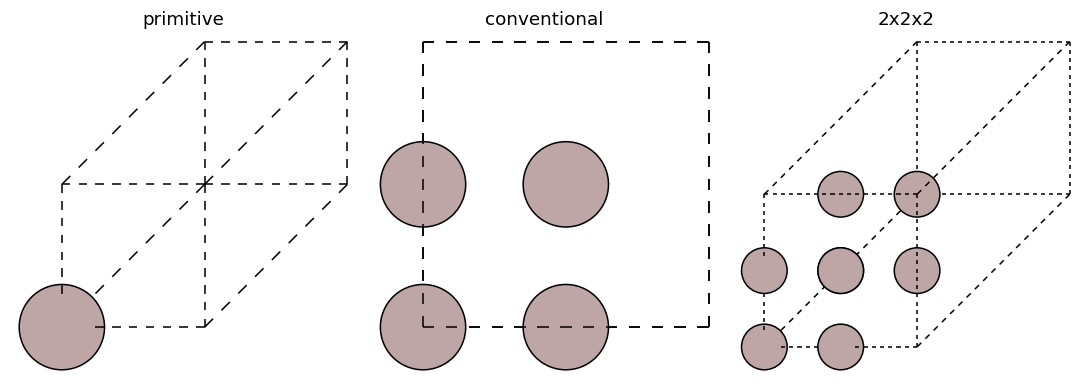

In [ ]:
prim = bulk('Al', 'fcc', a=4.05)
conv = bulk('Al', 'fcc', a=4.05, cubic=True)
sc222 = prim.repeat((2, 2, 2))

print(f'Primitive cell:    {len(prim)} atom(s)')
print(f'Conventional cell: {len(conv)} atom(s)')
print(f'2x2x2 supercell:   {len(sc222)} atom(s)')

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, atoms) in zip(axes, [('primitive', prim), ('conventional', conv), ('2x2x2', sc222)]):
    plot_atoms(atoms, ax, radii=0.5, show_unit_cell=2)
    ax.set_title(name)
    ax.set_axis_off()
plt.tight_layout()
plt.show()


In [ ]:
from ase.visualize import view

# the 2x2x2 supercell
view(sc222, viewer='x3d')  # drag to rotate, scroll to zoom


Question: DFT calculations almost always use the **primitive** cell for a bulk crystal, even though the conventional cell describes exactly the same infinite solid. Given that computational cost grows steeply with the number of atoms in the cell, why is the primitive cell the natural choice?

## Part 1 — A single SCF run with a 'reasonable first guess'

Aluminum is a **metal**: at zero temperature, bands are partially filled right up to the Fermi level, and the occupation numbers change discontinuously as bands cross it. This makes SCF convergence numerically difficult, so metals are normally run with a small artificial **smearing** of the occupations (`occupations='smearing'`), which we remove in spirit by keeping the smearing width small.

In [ ]:
input_data = {
    'control': {'calculation': 'scf', 'pseudo_dir': 'pseudo', 'outdir': 'out',
                'tprnfor': True, 'tstress': True},  # print forces & stress too
    'system': {
        'ecutwfc': 25,       # a REASONABLE starting guess -- we will test this below
        'ecutrho': 200,
        'occupations': 'smearing', 'smearing': 'gaussian', 'degauss': 0.02,
    },
    'electrons': {'conv_thr': 1.0e-8},
}

atoms = bulk('Al', 'fcc', a=4.05)
atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=input_data,
                       kpts=(4, 4, 4))   # also just a starting guess
e0 = atoms.get_potential_energy()
print(f'Al: E = {e0:.4f} eV  ({e0/len(atoms):.4f} eV/atom)')


Al: E = -91.0051 eV  (-91.0051 eV/atom)


### What's different in a periodic solid's output file in comparison to molecule's output file

A periodic solid's `espresso.pwo` has an actual **k-point list** (not just Gamma point). Also since we now turned on `tprnfor`/`tstress` above, the computed **forces** on each atom and the **stress tensor** is also included.

In [ ]:
!echo '--- k-points QE actually used ---'
!grep -A6 'number of k points' espresso.pwo
!echo
!echo '--- forces on each atom ---'
!grep -A4 'Forces acting on atoms' espresso.pwo
!echo
!echo '--- stress tensor ---'
!grep -A4 'total   stress' espresso.pwo


--- k-points QE actually used ---
     number of k points=     8  Gaussian smearing, width (Ry)=  0.0200
                       cart. coord. in units 2pi/alat
        k(    1) = (   0.0000000   0.0000000   0.0000000), wk =   0.0312500
        k(    2) = (   0.1767767   0.1767767  -0.1767767), wk =   0.2500000
        k(    3) = (  -0.3535534  -0.3535534   0.3535534), wk =   0.1250000
        k(    4) = (   0.3535534   0.0000000   0.0000000), wk =   0.1875000
        k(    5) = (  -0.1767767  -0.5303301   0.5303301), wk =   0.7500000

--- forces on each atom ---
     Forces acting on atoms (cartesian axes, Ry/au):

     atom    1 type  1   force =     0.00000000    0.00000000    0.00000000

     Total force =     0.000000     Total SCF correction =     0.000000

--- stress tensor ---
          total   stress  (Ry/bohr**3)                   (kbar)     P=        4.05
   0.00002751  -0.00000000  -0.00000000            4.05       -0.00       -0.00
  -0.00000000   0.00002751  -0.00000000    

Question: For this perfect, unrelaxed Al crystal, do you expect the forces on each atom to be exactly zero, close to zero, or something else entirely? What would a *nonzero* force on every atom be telling you about the structure you gave QE?

Question: Notice the number of k-points printed in the output file. Do they match with the number of k-points mentioned in the input? What is wk printed along with the k-points?

## Part 2 — Plane-wave cutoff (Ecut) convergence

In [ ]:
ecut_values = [15, 20, 25, 30, 35, 40, 45, 50]  # Ry
ecut_energies = []

for ecut in ecut_values:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = ecut
    d['system']['ecutrho'] = 8 * ecut
    a = bulk('Al', 'fcc', a=4.05)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=d, kpts=(4, 4, 4))
    ecut_energies.append(a.get_potential_energy() / len(a))
    print(f'ecutwfc = {ecut:>3} Ry   E = {ecut_energies[-1]:.5f} eV/atom')


ecutwfc =  15 Ry   E = -90.97025 eV/atom
ecutwfc =  20 Ry   E = -91.00300 eV/atom
ecutwfc =  25 Ry   E = -91.00514 eV/atom
ecutwfc =  30 Ry   E = -91.00531 eV/atom
ecutwfc =  35 Ry   E = -91.00537 eV/atom
ecutwfc =  40 Ry   E = -91.00540 eV/atom
ecutwfc =  45 Ry   E = -91.00544 eV/atom
ecutwfc =  50 Ry   E = -91.00547 eV/atom


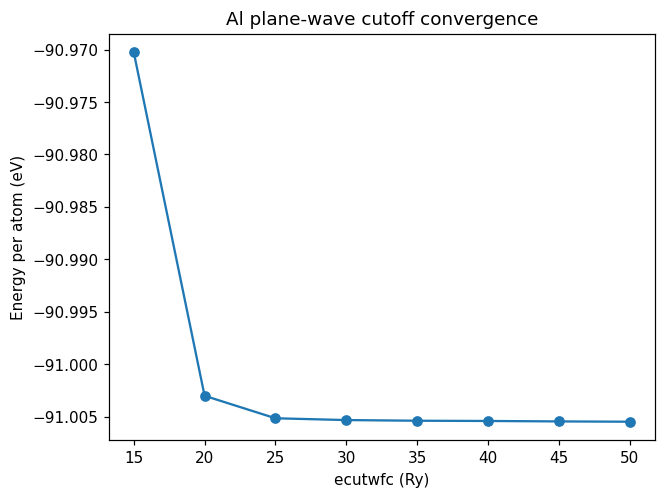

In [ ]:
plt.plot(ecut_values, ecut_energies, 'o-')
plt.xlabel('ecutwfc (Ry)')
plt.ylabel('Energy per atom (eV)')
plt.title('Al plane-wave cutoff convergence')
plt.show()

# Picking a converged cutoff: e.g. the smallest ecut whose energy is within
# 1 meV/atom of the highest-ecut result.
converged_ecutwfc = 30


## Part 3 — k-point convergence, and visualizing the Brillouin zone

In [ ]:
kgrids = [2, 3, 4, 5, 6, 8, 10, 12, 14]
kpt_energies = []

for n in kgrids:
    d = dict(input_data)
    d['system'] = dict(input_data['system'])
    d['system']['ecutwfc'] = converged_ecutwfc
    d['system']['ecutrho'] = 8 * converged_ecutwfc
    a = bulk('Al', 'fcc', a=4.05)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=d, kpts=(n, n, n))
    kpt_energies.append(a.get_potential_energy() / len(a))
    print(f'{n}x{n}x{n} k-mesh   E = {kpt_energies[-1]:.5f} eV/atom')


2x2x2 k-mesh   E = -91.94450 eV/atom
3x3x3 k-mesh   E = -90.71349 eV/atom
4x4x4 k-mesh   E = -91.00531 eV/atom
5x5x5 k-mesh   E = -91.22465 eV/atom
6x6x6 k-mesh   E = -91.33638 eV/atom
8x8x8 k-mesh   E = -91.26458 eV/atom
10x10x10 k-mesh   E = -91.25597 eV/atom
12x12x12 k-mesh   E = -91.27738 eV/atom
14x14x14 k-mesh   E = -91.26368 eV/atom


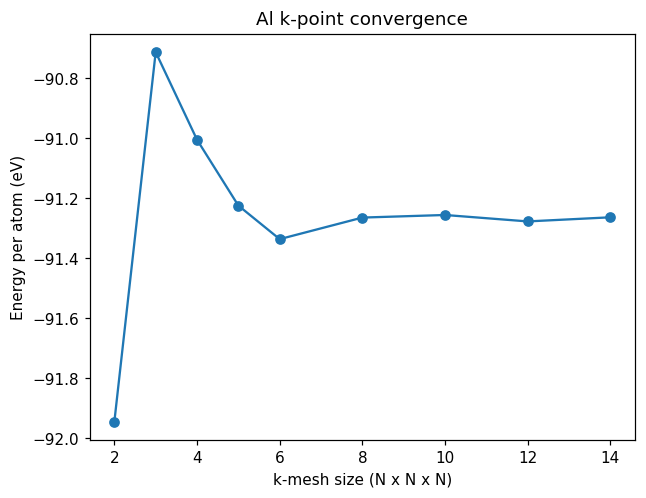

In [ ]:
plt.plot(kgrids, kpt_energies, 'o-')
plt.xlabel('k-mesh size (N x N x N)')
plt.ylabel('Energy per atom (eV)')
plt.title('Al k-point convergence')
plt.show()

converged_kpts = 10  # <-- read this off the plot


Question: How does the computational time scale with the k-point grid?

FCC(a=4.05)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



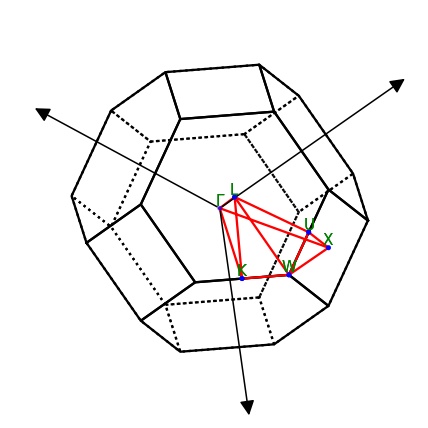

<Axes3D: >

In [ ]:
# Visualize the Brillouin zone itself, with high-symmetry points labeled,
# so 'k-point density' stops being an abstract number.
prim = bulk('Al', 'fcc', a=4.05)
lat = prim.cell.get_bravais_lattice()
print(lat.description())
lat.plot_bz(show=True)


## Part 4 — Equation of state: lattice constant and bulk modulus

We scan the lattice constant around our starting guess, compute the energy at each volume with our now-converged Ecut/k-mesh, and fit an equation of state.

### Fitting the equation of state

Rather than hand-rolling a polynomial fit, we use ASE's built-in `EquationOfState` class, which fits a Birch–Murnaghan equation of state to `(volume, energy)` pairs and returns the equilibrium volume $V_0$, energy $E_0$, and **bulk modulus $B_0$** directly.

In [ ]:
scale_factors = np.linspace(0.94, 1.06, 7)
volumes, eos_energies = [], []

d = dict(input_data)
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc
d['system']['ecutrho'] = 8 * converged_ecutwfc

for s in scale_factors:
    a = bulk('Al', 'fcc', a=4.05 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=d,
                       kpts=(converged_kpts, converged_kpts, converged_kpts))
    volumes.append(a.get_volume())
    eos_energies.append(a.get_potential_energy())
    print(f'a scale = {s:.3f}   V = {volumes[-1]:.2f} A^3   E = {eos_energies[-1]:.4f} eV')


a scale = 0.940   V = 13.79 A^3   E = -91.1100 eV
a scale = 0.960   V = 14.69 A^3   E = -91.1980 eV
a scale = 0.980   V = 15.63 A^3   E = -91.2439 eV
a scale = 1.000   V = 16.61 A^3   E = -91.2560 eV
a scale = 1.020   V = 17.62 A^3   E = -91.2409 eV
a scale = 1.040   V = 18.68 A^3   E = -91.2043 eV
a scale = 1.060   V = 19.78 A^3   E = -91.1513 eV


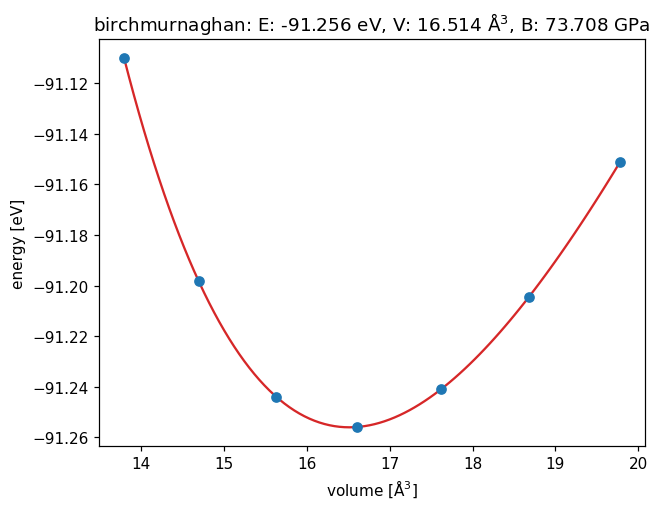

Equilibrium volume: 16.51 A^3, Lattice para: 2.55 A per primitive cell
Bulk modulus B0: 73.7 GPa


In [ ]:
eos = EquationOfState(volumes, eos_energies, eos='birchmurnaghan')
v0, e0, B = eos.fit()
a0 = (v0 * 1) ** (1 / 3)
B_GPa = B / 6.242e-3   # eV/A^3 -> GPa

eos.plot()
plt.show()
print(f'Equilibrium volume: {v0:.2f} A^3, Lattice para: {a0:.2f} A per primitive cell')
print(f'Bulk modulus B0: {B_GPa:.1f} GPa')


Question: Look up the experimental lattice constant and bulk modulus of Al. Do they match. What are the most likely causes of mismatch with the experimental values?

## Part 5 — Band structure and projected density of states

Band structures are computed **non-self-consistently**: first an SCF run converges the electron density, then a second run reuses that density and just diagonalizes the Hamiltonian along a path of high-symmetry k-points through the Brillouin zone.

In [ ]:
a_eq = bulk('Al', 'fcc', a=a0)

# Step 1: SCF at the equilibrium geometry, to get a converged density
scf_data = dict(input_data)
scf_data['control'] = dict(input_data['control'])
scf_data['system'] = dict(input_data['system'])
scf_data['system']['ecutwfc'] = converged_ecutwfc
scf_data['system']['ecutrho'] = 8 * converged_ecutwfc
a_eq.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials, input_data=scf_data,
                      kpts=(converged_kpts, converged_kpts, converged_kpts))
a_eq.get_potential_energy()


-70.1446904837628

In [ ]:
# Step 2: a band path through the standard high-symmetry points for this
# Bravais lattice, then a non-self-consistent 'bands' run along it.
path = a_eq.cell.bandpath(npoints=250)
print(path)  # shows which special points ASE picked for this lattice, e.g. G, X, W, K, L

bands_data = dict(scf_data)
bands_data['control'] = dict(scf_data['control'])
bands_data['control']['calculation'] = 'bands'
bands_data['control']['verbosity'] = 'high'   # <-- pw.x won't print eigenvalues for this many k-points otherwise

a_bands = bulk('Al', 'fcc', a=a0)
a_bands.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                         input_data=bands_data, kpts=path)

results_bands = a_bands.get_properties(['eigenvalues'])



BandPath(path='GXWKGLUWLK,UX', cell=[3x3], special_points={GKLUWX}, kpts=[250x3])


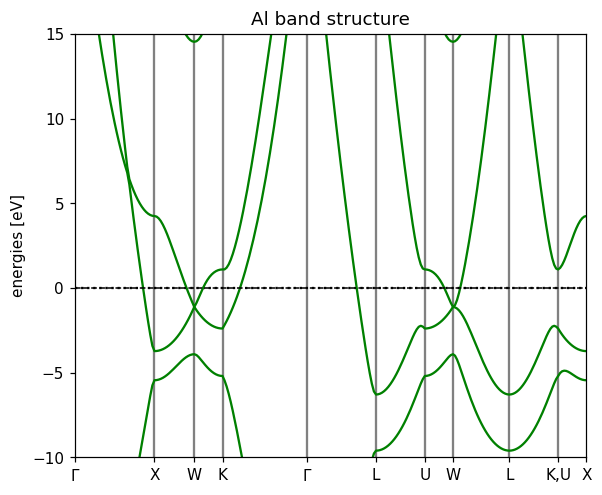

In [ ]:
from ase.spectrum.band_structure import BandStructure
bs = BandStructure(
    path=path,
    energies=results_bands['eigenvalues'],
    reference=a_eq.calc.get_fermi_level(),
)

bs = bs.subtract_reference()

fig, ax = plt.subplots(figsize=(6, 5))
bs.plot(ax=ax, emin=-10, emax=15)
ax.axhline(0, color='k', linestyle='--', linewidth=1)  # mark E_Fermi explicitly
ax.set_title('Al band structure')
plt.show()


In [ ]:
# Projected (orbital-resolved) density of states, via QE's projwfc.x.
# We run a denser non-self-consistent (nscf) calculation first, then
# project the wavefunctions onto atomic orbitals.
nscf_data = dict(scf_data)
nscf_data['control'] = dict(scf_data['control'])
nscf_data['control']['calculation'] = 'nscf'
nscf_data['system'] = dict(scf_data['system'])
nscf_data['system']['nosym'] = True

a_nscf = bulk('Al', 'fcc', a=a0)
a_nscf.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                        input_data=nscf_data, kpts=(12, 12, 12))

from ase.calculators.calculator import PropertyNotImplementedError, PropertyNotPresent

try:
    a_nscf.get_properties(['eigenvalues'])
except (PropertyNotImplementedError, PropertyNotPresent):
    pass



In [ ]:
# projwfc.x reads the nscf run's output directory (same outdir/prefix)
# and writes one file per (atom, orbital).
projwfc_input = (
    "&PROJWFC\n"
    "  outdir='out',\n"
    "  prefix='pwscf',\n"
    "  filpdos='al_pdos',\n"
    "  degauss=0.02,\n"
    "  DeltaE=0.05,\n"
    "/\n"
)
with open('projwfc.in', 'w') as f:
    f.write(projwfc_input)
!projwfc.x -in projwfc.in > projwfc.out
!ls *pdos*


'al_pdos.pdos_atm#1(Al)_wfc#1(s)'   al_pdos.pdos_tot
'al_pdos.pdos_atm#1(Al)_wfc#2(p)'


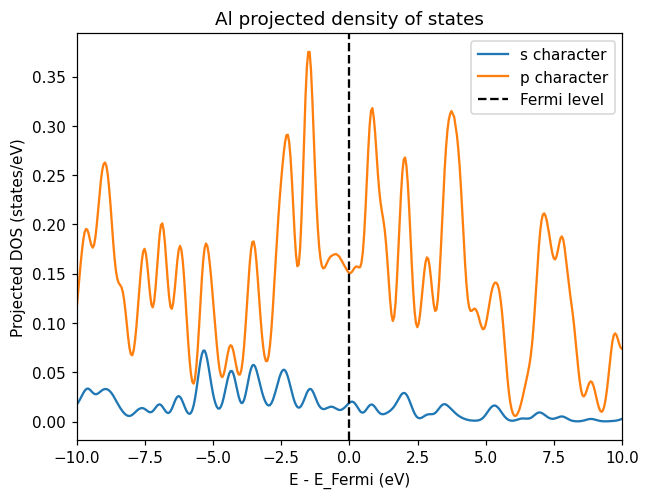

In [ ]:
import glob

fermi = a_eq.calc.get_fermi_level()

def read_pdos_file(fname):
    """QE pdos files: col 0 = energy (eV), col 1 = ldos, cols 2.. = per-m pdos."""
    data = np.loadtxt(fname, comments='#')
    energy = data[:, 0] - fermi
    pdos = data[:, 2:].sum(axis=1)  # sum over m to get the orbital's total pdos
    return energy, pdos

s_files = glob.glob('al_pdos.pdos_atm*wfc*(s)')
p_files = glob.glob('al_pdos.pdos_atm*wfc*(p)')

energy = None
s_pdos = p_pdos = None
for fn in s_files:
    en, pd = read_pdos_file(fn)
    energy = en
    s_pdos = pd if s_pdos is None else s_pdos + pd
for fn in p_files:
    en, pd = read_pdos_file(fn)
    p_pdos = pd if p_pdos is None else p_pdos + pd

plt.plot(energy, s_pdos, label='s character')
if p_pdos is not None:
    plt.plot(energy, p_pdos, label='p character')
plt.axvline(0, color='k', linestyle='--', label='Fermi level')
plt.xlabel('E - E_Fermi (eV)')
plt.ylabel('Projected DOS (states/eV)')
plt.title('Al projected density of states')
plt.legend()
plt.xlim(-10, 10)
plt.show()


Question: Which orbital character (s or p) dominates near the Fermi level for Al? Does that match with your expectation?

Question: How would a *projected* DOS for an insulator look like near E_Fermi?

## Part 6 — The pseudopotential approximation

In [ ]:
# Fetch just the Al SSSP pseudopotential (not the whole library this time --
# we only need one element here).
!mkdir -p pseudo_sssp
!wget -q -O SSSP.tar.gz https://archive.materialscloud.org/records/rcyfm-68h65/files/SSSP_1.3.0_PBE_efficiency.tar.gz
!tar -xzf SSSP.tar.gz -C pseudo_sssp


import glob, os, shutil

matches = glob.glob('pseudo_sssp/**/Al.*', recursive=True) + \
          glob.glob('pseudo_sssp/**/Al_*', recursive=True)
if not matches:
    raise RuntimeError(
        "Could not find an Al pseudopotential in the extracted SSSP archive. "
        "Run !find pseudo_sssp -iname '*al*' in a new cell to see what's "
        "actually in there, and adjust the glob pattern above to match."
    )

al_sssp_path = matches[0]
al_sssp_filename = os.path.basename(al_sssp_path)
if al_sssp_path != f'pseudo_sssp/{al_sssp_filename}':
    shutil.move(al_sssp_path, f'pseudo_sssp/{al_sssp_filename}')
print('SSSP Al pseudopotential:', al_sssp_filename)

SSSP Al pseudopotential: Al.pbe-n-kjpaw_psl.1.0.0.UPF


**A methodology shortcut, made explicit:** a fully rigorous comparison would re-run the Ecut and k-point convergence tests from Parts 2-3 for this new pseudopotential too, since different pseudopotentials can need different cutoffs to converge. For this example we'll reuse the GBRV-converged `converged_ecutwfc`/`converged_kpts` as a reasonable guess, although for publishable results this is not acceptable.

In [ ]:
pseudopotentials_sssp = {'Al': al_sssp_filename}

scale_factors = np.linspace(0.94, 1.06, 7)
volumes_sssp, energies_sssp = [], []

d = dict(input_data)
d['control'] = dict(input_data['control'])
d['control']['pseudo_dir'] = 'pseudo_sssp'
d['system'] = dict(input_data['system'])
d['system']['ecutwfc'] = converged_ecutwfc
d['system']['ecutrho'] = 8 * converged_ecutwfc

for s in scale_factors:
    a = bulk('Al', 'fcc', a=4.05 * s)
    a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials_sssp,
                       input_data=d, kpts=(converged_kpts, converged_kpts, converged_kpts))
    volumes_sssp.append(a.get_volume())
    energies_sssp.append(a.get_potential_energy())

eos_sssp = EquationOfState(volumes_sssp, energies_sssp, eos='birchmurnaghan')
v0_sssp, e0_sssp, B_sssp = eos_sssp.fit()
a0_sssp = v0_sssp ** (1 / 3)

print(f'GBRV: a0 = {a0:.4f} A')
print(f'SSSP: a0 = {a0_sssp:.4f} A')
print(f'Difference: {abs(a0 - a0_sssp):.4f} A  ({100*abs(a0 - a0_sssp)/a0:.2f}%)')


GBRV: a0 = 2.5465 A
SSSP: a0 = 2.5455 A
Difference: 0.0011 A  (0.04%)


Question: How does the GBRV-vs-SSSP difference in `a0` compare to DFT match with the experimental lattice constant? Is pseudopotential choice a small correction on top of everything else DFT assumes, or comparable in size to the other approximations you've already been making?

## Part 7 — Comparing energies of different phases

So far we have computed Al with FCC structure. But how do we know ground state phase of Al is FCC, and not say BCC. We can evaluate Al in a couple of *other*, purely hypothetical crystal structures too, using exactly the same E-vs-volume approach as Part 4, and see FCC is the lowest in energy.

In [ ]:
# Same recipe as Part 4's EOS scan, just repeated for three different
# structure types built from the same element. The lattice-constant
# guesses are chosen so all three start out around a similar volume per
# atom, so their curves actually overlap enough to compare meaningfully.
phase_structures = {
    'FCC':     ('fcc', 4.05),
    'BCC':     ('bcc', 3.20),
    'diamond': ('diamond', 6.00),
}

phase_input_data = dict(input_data)
phase_input_data['system'] = dict(input_data['system'])
phase_input_data['system']['ecutwfc'] = converged_ecutwfc
phase_input_data['system']['ecutrho'] = 8 * converged_ecutwfc

phase_data = {}   # name -> (volumes_per_atom, energies_per_atom)

for name, (structure_type, a_guess) in phase_structures.items():
    scales = np.linspace(0.88, 1.12, 7)
    vols, energies = [], []
    for s in scales:
        a = bulk('Al', structure_type, a=a_guess * s)
        a.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                           input_data=phase_input_data,
                           kpts=(converged_kpts, converged_kpts, converged_kpts))
        vols.append(a.get_volume() / len(a))
        energies.append(a.get_potential_energy() / len(a))
    phase_data[name] = (vols, energies)
    print(f'{name}: done')


FCC: done
BCC: done
diamond: done


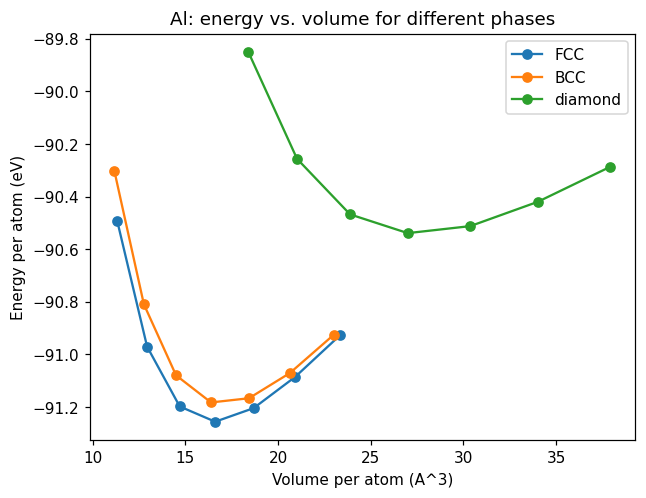

DFT predicts FCC has the lowest minimum energy per atom.


In [ ]:
fig, ax = plt.subplots()
for name, (vols, energies) in phase_data.items():
    ax.plot(vols, energies, 'o-', label=name)
ax.set_xlabel('Volume per atom (A^3)')
ax.set_ylabel('Energy per atom (eV)')
ax.set_title('Al: energy vs. volume for different phases')
ax.legend()
plt.show()

lowest = min(phase_data, key=lambda name: min(phase_data[name][1]))
print(f'DFT predicts {lowest} has the lowest minimum energy per atom.')


### Bonus: phase transition pressure via common tangent construction

At zero temperature, the pressure-driven transition between two phases happens at the volumes where their E(V) curves share a **common tangent line** — and that tangent line's slope is exactly $P = -dE/dV$.

In [ ]:
def lower_hull(points):
    """Andrew's monotone-chain algorithm, keeping only the LOWER hull"""
    pts = sorted(set(points))
    lower = []
    for p in pts:
        while len(lower) >= 2:
            (x1, y1), (x2, y2) = lower[-2], lower[-1]
            cross = (x2 - x1) * (p[1] - y1) - (y2 - y1) * (p[0] - x1)
            if cross <= 0:
                lower.pop()
            else:
                break
        lower.append(p)
    return lower


def transition_pressure(phase_data, name_A, name_B):
    """Combine two phases' (V, E) points, take the lower convex hull, and
    look for the hull segment that connects a point from phase A directly
    to a point from phase B. That segment's slope is dE/dV = -P at the
    predicted transition. Returns the pressure in GPa, or None if the
    two phases don't actually cross within the volumes you sampled --
    which is a perfectly legitimate outcome, not an error, and tells you
    one phase simply dominates throughout this range."""
    tagged = ([(v, e, name_A) for v, e in zip(*phase_data[name_A])]
              + [(v, e, name_B) for v, e in zip(*phase_data[name_B])])
    tagged.sort()
    hull = lower_hull([(v, e) for v, e, _ in tagged])
    lookup = {(v, e): label for v, e, label in tagged}
    hull_labels = [lookup[(v, e)] for v, e in hull]

    for i in range(len(hull) - 1):
        if hull_labels[i] != hull_labels[i + 1]:
            (v1, e1), (v2, e2) = hull[i], hull[i + 1]
            if abs(v2 - v1) < 0.05:
                # Two near-identical volumes from different phases landing next
                # to each other on the hull is a numerical artifact, not a real
                # tangent -- skip it and keep looking for a genuine crossing.
                continue
            slope = (e2 - e1) / (v2 - v1)     # eV / A^3
            P_transition = -slope * 160.2      # eV/A^3 -> GPa
            print(f'Common-tangent segment found between {hull_labels[i]} '
                  f'and {hull_labels[i + 1]}')
            print(f'Estimated transition pressure: {P_transition:.1f} GPa')
            return P_transition
    print(f'No well-resolved {name_A}-{name_B} common-tangent segment found -- '
          f'one phase is likely lower in energy everywhere in this volume range.')
    return None


transition_pressure(phase_data, 'FCC', 'BCC')


Common-tangent segment found between BCC and FCC
Estimated transition pressure: 199.7 GPa


np.float64(199.65578850505548)

Question: Try this for a different pair of phases (`transition_pressure(phase_data, 'FCC', 'diamond')`, for instance)

## Discuss / Explain

Answer all the "Questions" mentioned across this notebook.

## Assignment Exercises


1. **Do the fully rigorous version of Part 6**: re-run the Ecut and k-point convergence tests (Parts 2-3) using the SSSP pseudopotential instead of assuming GBRV's converged values carry over. Did SSSP converge at a similar Ecut, or a meaningfully different one?
2. **Finish the pseudopotential comparison from Part 6**: Now with the updated converged Ecut and k-points, repeat the bulk modulus fit *and* the band structure calculation using the SSSP pseudopotential instead of GBRV (reuse the `pseudopotentials_sssp` dict and `pseudo_dir='pseudo_sssp'` pattern). Does the band structure look qualitatively the same, or do you see real differences?
3. **Try a different metal ** — Cu or Ni are both FCC like Al and only need you to change the element symbol, lattice constant guess, and pseudopotential file. Redo all the sections of this notebook for either Cu of Ni. Compare obtained results on k-points, E_cut, bandstructure and phase energetics across chosen metal and Al?


## Summary

You've now run a complete periodic DFT workflow on Al: convergence testing, an equation of state, a band structure, and a projected DOS.

## References

- Giannozzi, P. et al. *QUANTUM ESPRESSO: a modular and open-source software project for quantum simulations of materials*. J. Phys.: Condens. Matter 21, 395502 (2009); and later updates (2017, 2020). https://www.quantum-espresso.org
- Larsen, A. H. et al. *The Atomic Simulation Environment — a Python library for working with atoms*. J. Phys.: Condens. Matter 29, 273002 (2017). https://wiki.fysik.dtu.dk/ase/
- Garrity, K. F., Bennett, J. W., Rabe, K. M. & Vanderbilt, D. *Pseudopotentials for high-throughput DFT calculations*. Comput. Mater. Sci. 81, 446 (2014). https://www.physics.rutgers.edu/gbrv/
